# Assignment 1

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jsmaskeen/DL-Assignment-1/blob/main/Assignment_1_whole.ipynb)

**Note:** Please run the `%%writefile` cells below to reconstruct the `src/` directory in your environment (e.g., Colab) before running the rest of the notebook.


## Writefile Setup


In [1]:
import os
os.makedirs('src', exist_ok=True)
os.makedirs('src/optimizers', exist_ok=True)


In [ ]:
%%writefile src/experiment.py
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Sequence

import hashlib

import numpy as np
import torch

from surfaces import SurfaceSpec
from viz import save_contour_plot, save_results_csv, save_trajectory_gif


@dataclass
class RunResult:
    surface: str
    optimizer_name: str
    trajectory: np.ndarray
    losses: np.ndarray
    reached_target: bool
    steps: int
    final_loss: float
    final_point: tuple[float, float]


OptimizerFactory = Callable[[], object]


def _is_offscreen(point: torch.Tensor, surface: SurfaceSpec) -> bool:
    x_value = float(point[0].item())
    y_value = float(point[1].item())
    return x_value < surface.xlim[0] or x_value > surface.xlim[1] or y_value < surface.ylim[0] or y_value > surface.ylim[1]


def _optimizer_state_snapshot(optimizer: object) -> dict[str, object] | None:
    state_dict = getattr(optimizer, "state_dict", None)
    if callable(state_dict):
        return state_dict()
    return None


def _optimizer_state_restore(optimizer: object, state: dict[str, object] | None) -> None:
    if state is None:
        return
    load_state_dict = getattr(optimizer, "load_state_dict", None)
    if callable(load_state_dict):
        load_state_dict(state)


def _stable_seed(surface_name: str, optimizer_name: str) -> int:
    digest = hashlib.sha256(f"{surface_name}:{optimizer_name}".encode("utf-8")).digest()
    return int.from_bytes(digest[:4], byteorder="big", signed=False)


def run_optimizer_on_surface(
    surface: SurfaceSpec,
    optimizer: object,
    learning_rate: float,
    max_steps: int = 1000,
    seed: int | None = None,
) -> RunResult:
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    point = torch.tensor(surface.start, dtype=torch.float32)
    trajectory: list[np.ndarray] = [point.numpy().copy()]
    losses: list[float] = []
    current_lr = learning_rate
    reached_target = False
    min_learning_rate = 1e-12

    for _ in range(max_steps):
        point = point.detach().requires_grad_(True)
        loss = surface.torch_fn(point)
        loss.backward()
        gradient = point.grad.detach()

        snapshot = _optimizer_state_snapshot(optimizer)
        next_point = point.detach()

        while True:
            tentative_point = optimizer.step(point.detach(), gradient, current_lr)
            if torch.isfinite(tentative_point).all() and not _is_offscreen(tentative_point, surface):
                next_point = tentative_point
                break

            current_lr *= 0.5
            _optimizer_state_restore(optimizer, snapshot)

            if current_lr < min_learning_rate:
                next_point = point.detach()
                break

        trajectory.append(next_point.detach().cpu().numpy().copy())
        losses.append(float(loss.item()))
        point = next_point.detach()

        if surface.is_target_reached(point):
            reached_target = True
            break

    final_point = (float(point[0].item()), float(point[1].item()))
    final_loss = float(surface.torch_fn(point).item())
    return RunResult(
        surface=surface.name,
        optimizer_name=getattr(optimizer, "name", optimizer.__class__.__name__),
        trajectory=np.asarray(trajectory, dtype=np.float32),
        losses=np.asarray(losses, dtype=np.float32),
        reached_target=reached_target,
        steps=len(trajectory) - 1,
        final_loss=final_loss,
        final_point=final_point,
    )


def run_task_suite(
    surfaces: Sequence[SurfaceSpec],
    optimizer_factories: Sequence[tuple[str, OptimizerFactory]],
    output_root: Path,
    max_steps: int = 1000,
) -> list[RunResult]:
    output_root.mkdir(parents=True, exist_ok=True)
    results: list[RunResult] = []

    for surface in surfaces:
        surface_runs: list[RunResult] = []
        for optimizer_name, factory in optimizer_factories:
            optimizer = factory()
            seed = _stable_seed(surface.name, optimizer_name)
            run_result = run_optimizer_on_surface(
                surface=surface,
                optimizer=optimizer,
                learning_rate=surface.default_learning_rate,
                max_steps=max_steps,
                seed=seed,
            )
            run_result.optimizer_name = optimizer_name
            results.append(run_result)
            surface_runs.append(run_result)

        surface_folder = output_root / surface.name.lower().replace(" ", "_")
        save_contour_plot(surface, surface_runs, surface_folder / "plots" / f"{surface.name.lower().replace(' ', '_')}.png")
        save_trajectory_gif(surface, surface_runs, surface_folder / "gifs" / f"{surface.name.lower().replace(' ', '_')}.gif")

    save_results_csv(
        [
            {
                "surface": result.surface,
                "optimizer": result.optimizer_name,
                "reached_target": result.reached_target,
                "steps": result.steps,
                "final_loss": result.final_loss,
                "final_x": result.final_point[0],
                "final_y": result.final_point[1],
            }
            for result in results
        ],
        output_root / "tables" / "results.csv",
    )

    return results


In [ ]:
%%writefile src/run_q1.py
from __future__ import annotations

from pathlib import Path

from experiment import run_task_suite
from optimizers import Adam, GradientDescent, Momentum, MinibatchSGD, SGD
from surfaces import Q1_SURFACES


def build_optimizer_factories() -> list[tuple[str, object]]:
    return [
        ("Gradient Descent", GradientDescent),
        ("Momentum", Momentum),
        ("SGD", SGD),
        ("Minibatch-SGD", MinibatchSGD),
        ("Adam", Adam),
    ]


def main() -> None:
    output_root = Path("../artifacts/Q1_loss_surfaces")
    run_task_suite(Q1_SURFACES, build_optimizer_factories(), output_root)


if __name__ == "__main__":
    main()


In [ ]:
%%writefile src/run_q2.py
from __future__ import annotations

from pathlib import Path

from experiment import run_task_suite
from optimizers import Adam, GradientDescent, Momentum, MinibatchSGD, SGD
from surfaces import Q2_SURFACES


def build_optimizer_factories() -> list[tuple[str, object]]:
    return [
        ("Gradient Descent", GradientDescent),
        ("Momentum", Momentum),
        ("SGD", SGD),
        ("Minibatch-SGD", MinibatchSGD),
        ("Adam", Adam),
    ]


def main() -> None:
    output_root = Path("../artifacts/Q2_rosenbrock")
    run_task_suite(Q2_SURFACES, build_optimizer_factories(), output_root)


if __name__ == "__main__":
    main()


In [ ]:
%%writefile src/run_q3.py
from __future__ import annotations
import math
from pathlib import Path
from typing import Sequence
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

from optimizers.adam import Adam
from experiment import run_optimizer_on_surface, RunResult
from surfaces import Q2_SURFACES
from viz import _evaluate_grid
import csv

class ScheduledAdam(Adam):
    def __init__(self, schedule_fn, name):
        super().__init__()
        self.schedule_fn = schedule_fn
        self.name = name
        self.lr_history = []

    def step(self, point, gradient, learning_rate):
        # Override the learning_rate with our scheduled rate
        lr = self.schedule_fn(self.t)
        self.lr_history.append(lr)
        return super().step(point, gradient, lr)

def get_schedules(eta_0: float, total_steps: int):
    eta_min = eta_0 * 0.01
    warmup = int(total_steps * 0.1)

    def constant(t): return eta_0
    def step_decay(t): return eta_0 * (0.1 ** (t // 600))
    def exp_decay(t): return eta_0 * (0.01 ** (t / total_steps))
    def cosine(t): return eta_min + 0.5 * (eta_0 - eta_min) * (1 + math.cos(math.pi * t / total_steps))
    def warmup_cosine(t):
        if t <= warmup:
            return (t / max(1, warmup)) * eta_0
        return eta_min + 0.5 * (eta_0 - eta_min) * (1 + math.cos(math.pi * (t - warmup) / (total_steps - warmup)))

    return [
        ("Constant", constant),
        ("Step Decay", step_decay),
        ("Exponential Decay", exp_decay),
        ("Cosine Annealing", cosine),
        ("Linear Warmup + Cosine", warmup_cosine),
    ]

def save_schedule_dual_gif(surface, runs: Sequence[RunResult], output_path: Path, fps: int = 30):
    output_path.parent.mkdir(parents=True, exist_ok=True)
    grid_x, grid_y, grid_z = _evaluate_grid(surface)
    max_length = max(run.trajectory.shape[0] for run in runs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), dpi=100)
    ax1.contour(grid_x, grid_y, grid_z, levels=35, cmap="viridis")

    line_artists = []
    point_artists = []
    lr_line_artists = []
    lr_point_artists = []
    for run in runs:
        (line,) = ax1.plot([], [], linewidth=1.5, label=run.optimizer_name)
        point = ax1.scatter([], [], s=25)
        (lr_line,) = ax2.plot([], [], linewidth=1.8, label=run.optimizer_name)
        lr_point = ax2.scatter([], [], s=25)

        line_artists.append(line)
        point_artists.append(point)
        lr_line_artists.append(lr_line)
        lr_point_artists.append(lr_point)

    step_text = ax1.text(0.02, 0.95, "", transform=ax1.transAxes, fontsize=11, bbox=dict(facecolor="white", alpha=0.8))
    ax1.set_xlim(*surface.xlim)
    ax1.set_ylim(*surface.ylim)
    ax1.set_title(f"Rosenbrock Trajectories")
    ax1.legend(loc="upper right", fontsize=7)

    ax2.set_xlim(0, max_length)
    # Estimate max LR to set y limit
    max_lr = max(max(run.lr_history) for run in runs if hasattr(run, "lr_history") and run.lr_history) if runs else 0.01
    ax2.set_ylim(0, max_lr * 1.1)
    ax2.set_title("Learning Rate Schedules η_t")
    ax2.legend(loc="upper right", fontsize=7)
    fig.tight_layout()

    def update(frame_index: int):
        # We sample 1000 frames evenly from max_length
        step = int(frame_index * (max_length / 1000)) if max_length > 1000 else frame_index
        if step >= max_length: step = max_length - 1

        for i, run in enumerate(runs):
            upper = min(step + 1, run.trajectory.shape[0])
            path = run.trajectory[:upper]
            line_artists[i].set_data(path[:, 0], path[:, 1])
            point_artists[i].set_offsets(path[-1])

            if hasattr(run, "lr_history") and run.lr_history:
                lrs = run.lr_history[:upper]
                lr_line_artists[i].set_data(range(len(lrs)), lrs)
                lr_point_artists[i].set_offsets((len(lrs)-1, lrs[-1]))

        step_text.set_text(f"step {step}")
        return [*line_artists, *point_artists, *lr_line_artists, *lr_point_artists, step_text]

    frames = min(max_length, 1000)
    animation = FuncAnimation(fig, update, frames=frames, interval=1000 / fps, blit=False)
    animation.save(output_path, writer=PillowWriter(fps=fps))
    plt.close(fig)

def save_schedule_loss_plot(runs: Sequence[RunResult], output_path: Path):
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=120)
    for run in runs:
        ax.plot(run.losses, label=run.optimizer_name, linewidth=1.8)
    ax.set_yscale("log")
    ax.set_title("Loss vs. Step across LR Schedules on Rosenbrock")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    fig.savefig(output_path, dpi=120)
    plt.close(fig)

def run_schedule_experiment(surface, schedules, output_root: Path, max_steps: int = 5000):
    output_root.mkdir(parents=True, exist_ok=True)
    results = []

    for name, fn in schedules:
        opt = ScheduledAdam(fn, name)
        # pass dummy lr=1.0 since ScheduledAdam ignores it
        res = run_optimizer_on_surface(surface, opt, learning_rate=1.0, max_steps=max_steps, seed=42)
        res.lr_history = opt.lr_history
        results.append(res)

    save_schedule_dual_gif(surface, results, output_root / "gifs" / "schedule_trajectories.gif")
    save_schedule_loss_plot(results, output_root / "plots" / "loss_vs_step.png")

    with open(output_root / "tables" / "results.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["Schedule", "Final loss", "Final x", "Final y", "Steps"])
        for res in results:
            writer.writerow([
                res.optimizer_name,
                f"{res.final_loss:.6f}",
                f"{res.final_point[0]:.6f}",
                f"{res.final_point[1]:.6f}",
                str(res.steps)
            ])

    return results

def main():
    schedules = get_schedules(0.5, 2000)
    rosenbrock = next(s for s in Q2_SURFACES if s.name == "Rosenbrock")
    run_schedule_experiment(rosenbrock, schedules, Path("../artifacts/Q3_lr_schedules"), 2000)

if __name__ == "__main__":
    main()


In [ ]:
%%writefile src/surfaces.py
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Optional, Tuple

import numpy as np
import torch

TensorFn = Callable[[torch.Tensor], torch.Tensor]
GridFn = Callable[[np.ndarray, np.ndarray], np.ndarray]


@dataclass(frozen=True)
class SurfaceSpec:
    name: str
    torch_fn: TensorFn
    grid_fn: GridFn
    start: Tuple[float, float]
    xlim: Tuple[float, float]
    ylim: Tuple[float, float]
    default_learning_rate: float
    minimum_point: Optional[Tuple[float, float]] = None
    minimum_tolerance: float = 1e-3
    escape_threshold: Optional[float] = None
    escape_measure: Optional[Callable[[torch.Tensor], torch.Tensor]] = None

    def is_target_reached(self, point: torch.Tensor) -> bool:
        if self.minimum_point is not None:
            minimum = torch.tensor(self.minimum_point, dtype=point.dtype, device=point.device)
            return bool(torch.linalg.norm(point - minimum) <= self.minimum_tolerance)

        if self.escape_threshold is not None and self.escape_measure is not None:
            return bool(self.escape_measure(point) >= self.escape_threshold)

        return False


def bowl_torch(point: torch.Tensor) -> torch.Tensor:
    x, y = point[0], point[1]
    return x * x + y * y


def bowl_grid(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return x * x + y * y


def ravine_torch(point: torch.Tensor) -> torch.Tensor:
    x, y = point[0], point[1]
    return x * x + 200.0 * y * y


def ravine_grid(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return x * x + 200.0 * y * y


def saddle_torch(point: torch.Tensor) -> torch.Tensor:
    x, y = point[0], point[1]
    return x * x - y * y


def saddle_grid(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return x * x - y * y


def rosenbrock_torch(point: torch.Tensor) -> torch.Tensor:
    x, y = point[0], point[1]
    return (1.0 - x) ** 2 + 100.0 * (y - x * x) ** 2


def rosenbrock_grid(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return (1.0 - x) ** 2 + 100.0 * (y - x * x) ** 2


Q1_SURFACES = [
    SurfaceSpec(
        name="Bowl",
        torch_fn=bowl_torch,
        grid_fn=bowl_grid,
        start=(-4.0, 4.0),
        xlim=(-5.0, 5.0),
        ylim=(-5.0, 5.0),
        default_learning_rate=0.08,
        minimum_point=(0.0, 0.0),
        minimum_tolerance=1e-3,
    ),
    SurfaceSpec(
        name="Ravine",
        torch_fn=ravine_torch,
        grid_fn=ravine_grid,
        start=(-4.0, 3.0),
        xlim=(-5.0, 5.0),
        ylim=(-4.0, 4.0),
        default_learning_rate=0.005,
        minimum_point=(0.0, 0.0),
        minimum_tolerance=1e-3,
    ),
    SurfaceSpec(
        name="Saddle",
        torch_fn=saddle_torch,
        grid_fn=saddle_grid,
        start=(-1.5, 0.001),
        xlim=(-3.0, 3.0),
        ylim=(-3.0, 3.0),
        default_learning_rate=0.05,
        escape_threshold=0.25,
        escape_measure=lambda point: torch.abs(point[1]),
    ),
]

Q2_SURFACES = [
    SurfaceSpec(
        name="Rosenbrock",
        torch_fn=rosenbrock_torch,
        grid_fn=rosenbrock_grid,
        start=(-1.5, 1.5),
        xlim=(-2.0, 2.0),
        ylim=(-1.0, 3.0),
        default_learning_rate=0.002,
        minimum_point=(1.0, 1.0),
        minimum_tolerance=1e-2,
    ),
]


In [ ]:
%%writefile src/viz.py
from __future__ import annotations

from pathlib import Path
from typing import Sequence

import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np

from surfaces import SurfaceSpec


def _evaluate_grid(surface: SurfaceSpec, resolution: int = 250) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    x_values = np.linspace(surface.xlim[0], surface.xlim[1], resolution)
    y_values = np.linspace(surface.ylim[0], surface.ylim[1], resolution)
    grid_x, grid_y = np.meshgrid(x_values, y_values)
    grid_z = surface.grid_fn(grid_x, grid_y)
    return grid_x, grid_y, grid_z


def save_contour_plot(surface: SurfaceSpec, runs: Sequence["RunResult"], output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    grid_x, grid_y, grid_z = _evaluate_grid(surface)

    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    ax.contour(grid_x, grid_y, grid_z, levels=35, cmap="viridis")

    for run in runs:
        path = run.trajectory
        ax.plot(path[:, 0], path[:, 1], linewidth=1.8, label=run.optimizer_name)
        ax.scatter(path[-1, 0], path[-1, 1], s=25)

    ax.set_xlim(*surface.xlim)
    ax.set_ylim(*surface.ylim)
    ax.set_title(f"{surface.name} trajectories")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    fig.savefig(output_path)
    plt.close(fig)


def save_trajectory_gif(surface: SurfaceSpec, runs: Sequence["RunResult"], output_path: Path, fps: int = 12) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    grid_x, grid_y, grid_z = _evaluate_grid(surface)
    max_length = max(run.trajectory.shape[0] for run in runs)

    fig, ax = plt.subplots(figsize=(8, 6), dpi=120)
    ax.contour(grid_x, grid_y, grid_z, levels=35, cmap="viridis")

    line_artists = []
    point_artists = []
    for run in runs:
        (line,) = ax.plot([], [], linewidth=2.0, label=run.optimizer_name)
        point = ax.scatter([], [], s=40)
        line_artists.append(line)
        point_artists.append(point)

    step_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, fontsize=11, bbox=dict(facecolor="white", alpha=0.8))
    ax.set_xlim(*surface.xlim)
    ax.set_ylim(*surface.ylim)
    ax.set_title(f"{surface.name} optimizer comparison")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()

    def update(frame_index: int):
        for line, point, run in zip(line_artists, point_artists, runs):
            upper = min(frame_index + 1, run.trajectory.shape[0])
            path = run.trajectory[:upper]
            line.set_data(path[:, 0], path[:, 1])
            point.set_offsets(path[-1])
        step_text.set_text(f"step {frame_index}")
        return [*line_artists, *point_artists, step_text]

    animation = FuncAnimation(fig, update, frames=max_length, interval=1000 / fps, blit=False)
    animation.save(output_path, writer=PillowWriter(fps=fps))
    plt.close(fig)


import csv

def save_results_csv(rows: Sequence[dict[str, object]], output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if not rows: return
    
    # Capitalize headers for the CSV
    headers = ["Surface", "Optimizer", "Reached target", "Steps", "Final loss", "Final x", "Final y"]
    
    with open(output_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        for row in rows:
            writer.writerow([
                row["surface"],
                row["optimizer"],
                "Yes" if bool(row["reached_target"]) else "No",
                row["steps"],
                f'{float(row["final_loss"]):.6f}',
                f'{float(row["final_x"]):.6f}',
                f'{float(row["final_y"]):.6f}',
            ])


from typing import TYPE_CHECKING

if TYPE_CHECKING:
    from experiment import RunResult


In [ ]:
%%writefile src/optimizers/adam.py
from __future__ import annotations

import torch


class Adam:
    name = "Adam"

    def __init__(self, beta1: float = 0.9, beta2: float = 0.999, eps: float = 1e-8) -> None:
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m: torch.Tensor | None = None
        self.v: torch.Tensor | None = None
        self.t = 0

    def step(self, point: torch.Tensor, gradient: torch.Tensor, learning_rate: float) -> torch.Tensor:
        if self.m is None or self.v is None:
            self.m = torch.zeros_like(point)
            self.v = torch.zeros_like(point)

        self.t += 1
        self.m = self.beta1 * self.m + (1.0 - self.beta1) * gradient
        self.v = self.beta2 * self.v + (1.0 - self.beta2) * (gradient * gradient)

        m_hat = self.m / (1.0 - self.beta1 ** self.t)
        v_hat = self.v / (1.0 - self.beta2 ** self.t)
        return point - learning_rate * m_hat / (torch.sqrt(v_hat) + self.eps)

    def state_dict(self) -> dict[str, object]:
        return {
            "m": None if self.m is None else self.m.clone(),
            "v": None if self.v is None else self.v.clone(),
            "t": self.t,
        }

    def load_state_dict(self, state: dict[str, object]) -> None:
        m = state.get("m")
        v = state.get("v")
        self.m = None if m is None else m.clone()
        self.v = None if v is None else v.clone()
        self.t = int(state.get("t", 0))


In [ ]:
%%writefile src/optimizers/gradient_descent.py
from __future__ import annotations

import torch


class GradientDescent:
    name = "Gradient Descent"

    def step(self, point: torch.Tensor, gradient: torch.Tensor, learning_rate: float) -> torch.Tensor:
        return point - learning_rate * gradient

    def state_dict(self) -> dict[str, object]:
        return {}

    def load_state_dict(self, state: dict[str, object]) -> None:
        return None


In [ ]:
%%writefile src/optimizers/momentum.py
from __future__ import annotations

import torch


class Momentum:
    name = "Momentum"

    def __init__(self, beta: float = 0.9) -> None:
        self.beta = beta
        self.velocity: torch.Tensor | None = None

    def step(self, point: torch.Tensor, gradient: torch.Tensor, learning_rate: float) -> torch.Tensor:
        if self.velocity is None:
            self.velocity = torch.zeros_like(point)
        self.velocity = self.beta * self.velocity + gradient
        return point - learning_rate * self.velocity

    def state_dict(self) -> dict[str, object]:
        return {"velocity": None if self.velocity is None else self.velocity.clone()}

    def load_state_dict(self, state: dict[str, object]) -> None:
        velocity = state.get("velocity")
        self.velocity = None if velocity is None else velocity.clone()


In [ ]:
%%writefile src/optimizers/sgd.py
from __future__ import annotations

import math

import torch


class SGD:
    name = "SGD"

    def __init__(self, noise_scale: float = 0.15) -> None:
        self.noise_scale = noise_scale

    def step(self, point: torch.Tensor, gradient: torch.Tensor, learning_rate: float) -> torch.Tensor:
        noisy_gradient = gradient + self.noise_scale * torch.randn_like(gradient)
        return point - learning_rate * noisy_gradient

    def state_dict(self) -> dict[str, object]:
        return {}

    def load_state_dict(self, state: dict[str, object]) -> None:
        return None


class MinibatchSGD:
    name = "Minibatch-SGD"

    def __init__(self, noise_scale: float = 0.15, batch_size: int = 16) -> None:
        self.noise_scale = noise_scale
        self.batch_size = max(1, batch_size)

    def step(self, point: torch.Tensor, gradient: torch.Tensor, learning_rate: float) -> torch.Tensor:
        effective_noise = self.noise_scale / math.sqrt(float(self.batch_size))
        noisy_gradient = gradient + effective_noise * torch.randn_like(gradient)
        return point - learning_rate * noisy_gradient

    def state_dict(self) -> dict[str, object]:
        return {}

    def load_state_dict(self, state: dict[str, object]) -> None:
        return None


In [ ]:
%%writefile src/optimizers/__init__.py
from .adam import Adam
from .gradient_descent import GradientDescent
from .momentum import Momentum
from .sgd import MinibatchSGD, SGD

__all__ = [
    "Adam",
    "GradientDescent",
    "Momentum",
    "MinibatchSGD",
    "SGD",
]


# Q1: Optimizers on Loss Surfaces

Testing Gradient Descent, Momentum, SGD, Minibatch-SGD, and Adam across three loss surfaces:
- **Bowl**: $L(x,y) = x^2 + y^2$
- **Ravine**: $L(x,y) = x^2 + 200y^2$
- **Saddle**: $L(x,y) = x^2 - y^2$

In [7]:
from IPython.display import Image, display, Markdown
from pathlib import Path
import pandas as pd

output_dir = 'https://raw.githubusercontent.com/jsmaskeen/DL-Assignment-1/refs/heads/main/artifacts/Q1_loss_surfaces'
output_media_dir = 'https://media.githubusercontent.com/media/jsmaskeen/DL-Assignment-1/main/artifacts/Q1_loss_surfaces'


## Summary Table

In [5]:
df = pd.read_csv(output_dir + '/' + 'tables' + '/' + 'results.csv')
display(df)

,Surface,Optimizer,Reached target,Steps,Final loss,Final x,Final y
0,Bowl,Gradient Descent,Yes,50,0.000001,-0.000655,0.000655
1,Bowl,Momentum,Yes,111,0.000001,0.000612,-0.000612
2,Bowl,SGD,Yes,848,0.000000,-0.000039,-0.000052
3,Bowl,Minibatch-SGD,Yes,203,0.000001,-0.000484,0.000699
4,Bowl,Adam,Yes,144,0.000000,0.000496,-0.000496
5,Ravine,Gradient Descent,No,1000,1800.000000,-0.000173,3.000000
6,Ravine,Momentum,Yes,130,0.000181,0.000147,-0.000950
7,Ravine,SGD,No,1000,1780.834351,-0.002060,2.983986
8,Ravine,Minibatch-SGD,No,1000,1794.060181,0.000133,2.995046
9,Ravine,Adam,No,1000,7.742406,-0.642013,0.191445


## Trajectories

### Bowl

In [8]:
display(Image(url=str(output_media_dir + '/' + 'bowl' + '/' + 'gifs' + '/' + 'bowl.gif')))

### Ravine

In [9]:
display(Image(url=str(output_media_dir + '/' + 'ravine' + '/' + 'gifs' + '/' + 'ravine.gif')))

### Saddle

In [10]:
display(Image(url=str(output_media_dir + '/' + 'saddle' + '/' + 'gifs' + '/' + 'saddle.gif')))

## Observations and Explanations
### Bowl (Simple Convex)
- All optimizers easily find the minimum. 
- **Gradient Descent** converges extremely fast in just 50 steps because the surface has uniform curvature ($x^2 + y^2$).
- **SGD** and **Minibatch-SGD** take longer due to the added noise which causes them to bounce around the minimum before reaching the target tolerance.

### Ravine (Ill-conditioned)
- Only **Momentum** succeeds in reaching the minimum within 1000 steps (130 steps).
- The ravine has very steep walls along the $y$-axis (due to $200y^2$) and a very flat bottom along the $x$-axis. Gradient Descent, SGD, and Minibatch-SGD bounce back and forth along the $y$-axis walls while making very little progress along $x$.
- Momentum dampens the oscillations across the walls and accelerates progress along the flat bottom, efficiently solving the ill-conditioned curvature.
- Adam struggles here possibly due to its adaptive scaling making the learning rate too small along the slow axis, leading to no convergence within 1000 steps.

### Saddle (Escaping Saddle Point)
- The assignment asks to report how many steps it took to move clearly away from the center (defined as $|y| \ge 0.25$).
- **Adam** escapes the saddle extremely quickly (just 6 steps) because its adaptive learning rate scales up the very small initial gradient along the escape direction ($y$-axis).
- **Momentum** also escapes quickly (22 steps) by accumulating velocity.
- The standard **Gradient Descent** and **SGD/Minibatch-SGD** variants take slightly longer (around 45-60 steps) but still successfully escape because the starting point (-1.5, 0.001) is slightly off-center along $y$, allowing the gradient in that direction to eventually grow.

# Q2: Optimizers on Rosenbrock Surface

Evaluating optimizers on the Rosenbrock surface:
$$L(x,y) = (1 - x)^2 + 100(y - x^2)^2$$
Start point: $(-1.5, 1.5)$, Minimum: $(1, 1)$.

In [15]:
from IPython.display import Image, display, Markdown
from pathlib import Path
import pandas as pd

output_dir = 'https://raw.githubusercontent.com/jsmaskeen/DL-Assignment-1/refs/heads/main/artifacts/Q2_rosenbrock'
output_media_dir = 'https://media.githubusercontent.com/media/jsmaskeen/DL-Assignment-1/main/artifacts/Q2_rosenbrock'



## Summary Table

In [16]:
df = pd.read_csv(output_dir + '/' + 'tables' + '/' + 'results.csv')
display(df)

,Surface,Optimizer,Reached target,Steps,Final loss,Final x,Final y
0,Rosenbrock,Gradient Descent,No,1000,0.072170,0.731647,0.534055
1,Rosenbrock,Momentum,Yes,529,0.000020,0.995561,0.991124
2,Rosenbrock,SGD,No,1000,0.073427,0.729905,0.530580
3,Rosenbrock,Minibatch-SGD,No,1000,0.072334,0.731349,0.533605
4,Rosenbrock,Adam,No,1000,5.195003,-1.278426,1.640519


## Trajectories

In [17]:
display(Image(url=str(output_media_dir + '/' + 'rosenbrock' + '/' + 'gifs' + '/' + 'rosenbrock.gif')))

## Observations & Analysis

- **Curved Valley Geometry**: The global minimum $(1, 1)$ lies inside a steep parabolic valley $y = x^2$. Isotropic methods like GD oscillate across the steep walls rather than progressing down the valley.
- **Hessian Ill-Conditioning**: The high condition number of the Hessian makes step sizes along the valley floor small.
- **Adaptive Scaling**: **Adam** scales updates by second-moment estimates, allowing fast movement along the valley floor while stabilizing cross-valley oscillations.

## Observations and Explanations
### Why is Rosenbrock harder to optimize than Q1 surfaces?
The Rosenbrock function, $L(x,y) = (1-x)^2 + 100(y-x^2)^2$, is notoriously difficult to optimize. 
- **Non-convex Valley:** Unlike the Bowl or Ravine (which are convex), the Rosenbrock function has a deep, narrow, and curved (parabolic) valley. 
- **Ill-conditioning:** Similar to the Ravine, the gradients are very steep on the walls of the valley (due to the factor of 100) and extremely flat along the floor of the curved valley.
- **Changing Curvature:** As the optimizers travel along the valley floor to reach the global minimum at (1,1), the direction of the valley curves.

**Optimizer Performance:**
1. **Gradient Descent, SGD, and Minibatch-SGD**
   - **Performance**: They fail to reach the target within 1000 steps, getting stuck around $(x \approx 0.73, y \approx 0.53)$.
   - **Reason**: They are forced to use a very small learning rate (0.002) to avoid diverging on the steep walls initially. However, once they reach the flat valley floor, this small learning rate causes them to make agonizingly slow progress along the valley towards the minimum.
   - **Comparison to Q1**: This is similar to their failure in the Q1 Ravine, but compounded by the fact that the valley curves.

2. **Momentum**
   - **Performance**: The only optimizer to successfully reach the minimum (in 529 steps).
   - **Reason**: Momentum accumulates velocity along the valley floor, speeding up the optimization where gradients are very small, while dampening the oscillations across the steep walls.
   - **Comparison to Q1**: Just like it was the only optimizer to solve the Q1 Ravine, Momentum proves highly effective at navigating steep, narrow valleys.

3. **Adam**
   - **Performance**: Fails to reach the target within 1000 steps, ending up farther from the minimum than standard Gradient Descent.
   - **Reason**: On the Q1 Ravine, Adam was simply slow — its loss dropped over 99% and it kept moving steadily toward the minimum, just not fast enough to finish in time. Rosenbrock is different: Adam sets its step size using an average of *past* gradients, which works well when the steep and flat directions stay fixed (as in the Ravine), but Rosenbrock's valley curves, so the "steep" and "flat" directions keep rotating as x and y interact. Adam's step size lags behind this shift, so its steps end up pointed the wrong way rather than just being too small — causing it to overshoot and lose ground instead of slowly closing in.
   - **Comparison to Q1**: On the Ravine, Adam was heading the right way, just too slowly. On Rosenbrock, it actively moves the wrong way — showing that Adam struggles not with ill-conditioning itself, but with ill-conditioning that keeps changing direction.

# Q3: Learning-Rate Schedules with Adam

The Rosenbrock surface is somewhat weird. It has very steep walls on all sides of the valley and valley is parabolic and also very narrow. So we have two problems - the optimizer should first reach the valley without overshooting and secondly we want to make sure the optimizer follows the parabolic valley to the minimum without bumping arounds the walls too much. The optimizer should essentially switch from a very steep wall to a very narrow and not as steep valley and then follow the valley properly.

The different LR Sschedules we will use are:

- Step decay: Decay by factor of 0.1 after K steps
- **Exponential Decay** $\eta_t = \eta_0\,\gamma^t$;
- **Cosine annealing** $\eta_t = \eta_{\min} + \frac{1}{2}(\eta_0 - \eta_{\min})\left(1 + \cos\left(\frac{\pi t}{T}\right)\right)$ (Has a absolute minimum value and reduces the LR similar to the decreasing side of a cosine curve)
- **Linear warmup plus cosine decay**. (Slowly increase the LR to a point and then use cosine decay)

$$z
\eta_t =
\begin{cases}
\dfrac{t}{T_{\mathrm{warmup}}}\,\eta_0, & t \le T_{\mathrm{warmup}}, \\
\eta_{\min} + \dfrac{1}{2}(\eta_0 - \eta_{\min})\left(1 + \cos\left(\dfrac{\pi (t - T_{\mathrm{warmup}})}{T - T_{\mathrm{warmup}}}\right)\right), & t > T_{\mathrm{warmup}}.
\end{cases}
$$

In [18]:
from IPython.display import Image, display
from pathlib import Path
import pandas as pd

output_dir = 'https://raw.githubusercontent.com/jsmaskeen/DL-Assignment-1/refs/heads/main/artifacts/Q3_lr_schedules'
output_media_dir = 'https://media.githubusercontent.com/media/jsmaskeen/DL-Assignment-1/main/artifacts/Q3_lr_schedules'



## Summary Table

In [19]:
df = pd.read_csv(output_dir + '/' + 'tables' + '/' + 'results.csv')
display(df)

,Schedule,Final loss,Final x,Final y,Steps
0,Constant,0.000020,0.995559,0.991124,649
1,Step Decay,0.000020,0.995528,0.991061,1042
2,Exponential Decay,0.000316,0.982246,0.964750,2000
3,Cosine Annealing,0.000020,0.995539,0.991083,711
4,Linear Warmup + Cosine,0.000020,0.995526,0.991058,838


### Experiment Parameters
According to the assignment doc, the parameters used are:
- Optimizer: Adam ($\beta_1=0.9$, $\beta_2=0.999$)
- Base Learning Rate ($\eta_0$): 0.5
- Min Learning Rate ($\eta_{min}$): 0.005
- Max Steps: 2000 
- Step Decay Period ($K$): 600 steps
- Cosine Annealing Period ($T$): 2000 steps
- Warmup Steps ($T_{warmup}$): 200 steps (10% of $T$)
- Surface: Rosenbrock starting at (-1.5, 1.5)


## Trajectory & Learning Rate Animations

In [20]:
display(Image(url=str(output_media_dir + '/' + 'gifs' + '/' + 'schedule_trajectories.gif')))

## Loss Curves

In [22]:
display(Image(url=str(output_dir + '/' + 'plots' + '/' + 'loss_vs_step.png')))

## Analysis

Notice we used a relatively large learning rate here, we wanted to show how the decaying learning rates would help for this surface, initially their learning rates would be high as required for the steep wall and by the time they reach the valley they would have slowed down. But what we find is suprising, the constant learning rate outperforms everything else! It seems like adding decaying LR schedules just makes the optimizer slower to reach the minima instead of helping at all. 

Cosine annealing is the next best scheduler, followed by warmup + cosine and then step decay. 

We had tried this with smaller learning rates and the results are the same (Actually here the difference in number of steps is atleast not too much - with smaller learning rates, constant wins over by a huge factor.)


The rosenbrock surface is fundamentally bad for optimizers like Adam. Adam updates x and y coordinates independently and calculates their momentums indepedently too. This is good when there is a fixed direction that is decreasing. But in the case of rosenbrock, the decreasing direction is parabolic. Since ADAM independently updates x and y it is harder for it to see this. Second order optimization methods like Newton's method can see this relation and hence are much better. We can notice this in the contour plots above too, how most of them bounce around the walls in the valley in the **early steps**.

**Notice also that linear warmup + cosine decay has the least amount of this jumping around behaviour in the beginning - so warmup actually helps the optimizer in the beginning**. The decay later on though leads to more steps taken than the constant LR schedule


# Q4. Dropout on Fashion MNIST

## Imports and Parameters

The required libraries are imported and the below parameters are set:
- 5000 Training Images
- 1000 Test Images
- 50 Epochs
- Batch Size 64
- Adam Optimizer with learning rate of $10^{-3}$
- Dropout probabilities of 0.0, 0.1, 0.25, 0.5, 0.75



In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import f1_score

SEED = 0
N_TRAIN = 5000
N_TEST = 1000
EPOCHS = 50
BATCH_SIZE = 64
LR = 1e-3
HIDDEN = [512, 256]
DROPOUT_PROBS = [0.0, 0.1, 0.25, 0.5, 0.75]
OUTDIR = "q4_outputs"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(OUTDIR, exist_ok=True)
print("Device:", device)

def set_seed(seed):
    """Same init and batch order for every model, so the only difference is p."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

Device: cuda


The dataset is loaded, shuffled and split into batches.

In [2]:
transform = transforms.ToTensor()

train_full = datasets.FashionMNIST(root="data", train=True,
                                   download=True, transform=transform)
test_full  = datasets.FashionMNIST(root="data", train=False,
                                   download=True, transform=transform)

def balanced_indices(dataset, n_total):
    per_class = n_total // 10
    targets = np.array(dataset.targets)
    rng = np.random.RandomState(SEED)
    idx = []
    for c in range(10):
        c_idx = np.where(targets == c)[0]
        idx.extend(rng.choice(c_idx, per_class, replace=False))
    rng.shuffle(idx)
    return list(idx)

train_set = Subset(train_full, balanced_indices(train_full, N_TRAIN))
test_set  = Subset(test_full,  balanced_indices(test_full,  N_TEST))

train_loader      = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
train_eval_loader = DataLoader(train_set, batch_size=512, shuffle=False)
test_loader       = DataLoader(test_set,  batch_size=512, shuffle=False)

print(len(train_set), "train images |", len(test_set), "test images")

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.6MB/s]

5000 train images | 1000 test images



/tmp/ipykernel_820/1116810077.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  targets = np.array(dataset.targets)


## MLP Architecture
For this question, we use a fully connected neural network. Input is 784 (Images are 28x28), and ReLU is used as activation. Dropout is used on every layer after the activation. The network consists of two hidden layers followed by the 10-dimensional output layer:

$$
784 \rightarrow 512 \rightarrow 256 \rightarrow 10
$$
Dropout probability represents the probability of setting a hidden unit to zero, during training. p = 0, corresponds to a MLP without any dropout. Dropout probability represents the probability of setting a hidden unit to zero, during trainng. With Dropout, shutting off some neurons at each layer forces the remaining network to learn redundant and robust features, rather than relying on other neighboring neurons to fix their mistakes.

In [3]:
class MLP(nn.Module):
    """784 -> 512 -> 256 -> 10, ReLU, dropout after each hidden activation.
       p = 0.0 gives the plain unregularised baseline."""
    def __init__(self, p=0.0, hidden=HIDDEN):
        super().__init__()
        layers = [nn.Flatten()]
        in_dim = 28 * 28
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU()]
            if p > 0:
                layers.append(nn.Dropout(p))
            in_dim = h
        layers.append(nn.Linear(in_dim, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

print(MLP(0.5))

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.5, inplace=False)
    (7): Linear(in_features=256, out_features=10, bias=True)
  )
)


## Evaluation Metrics

The model is evaluated using 3 metrics.
- Cross Entropy Loss: It measures error during training
- Accuracy : It measures the fraction of correctly classified images.
- F1- Score: It combines precison and recall, independently for each class and averages them.

During evaluation, dropout is disabled, which ensures test set and train set evaluation is deterministic.

At the end of every epoch, we evaluate the model on both the training and test subsets and record:
- training loss
- test loss
- training accuracy
- test accuracy
- training F1 score
- test F1 score

We also record the difference between training and test accuracy:

$$ \text{Accuracy Gap} = \text{Training Accuracy} - \text{Test Accuracy} $$

If this gap is positive it indicates that, model performs much better on training data than test data.
Macro F1-Score was used as each class is equally important.

In [4]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    """model.eval() disables dropout, so test-time metrics are deterministic."""
    model.eval()
    total_loss, n = 0.0, 0
    preds, trues = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        total_loss += criterion(out, y).item() * y.size(0)
        n += y.size(0)
        preds.append(out.argmax(1).cpu())
        trues.append(y.cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    return total_loss / n, (preds == trues).mean(), f1_score(trues, preds, average="macro")

def train_model(p):
    set_seed(SEED)
    model = MLP(p).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    history = []
    for epoch in range(1, EPOCHS + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        tr_loss, tr_acc, tr_f1 = evaluate(model, train_eval_loader, criterion)
        te_loss, te_acc, te_f1 = evaluate(model, test_loader, criterion)

        history.append(dict(dropout=p, epoch=epoch,
                            train_loss=tr_loss, test_loss=te_loss,
                            train_acc=tr_acc,   test_acc=te_acc,
                            train_f1=tr_f1,     test_f1=te_f1,
                            acc_gap=tr_acc - te_acc))

        if epoch % 10 == 0 or epoch == 1:
            print(f"  p={p:<5} epoch {epoch:>3}/{EPOCHS} | "
                  f"train acc {tr_acc:.4f} f1 {tr_f1:.4f} | "
                  f"test acc {te_acc:.4f} f1 {te_f1:.4f}")
    return model, pd.DataFrame(history)

In [5]:
all_hist = []
for p in DROPOUT_PROBS:
    print(f"\nTraining MLP with dropout p={p} ...")
    _, hist = train_model(p)
    all_hist.append(hist)

df = pd.concat(all_hist, ignore_index=True)
df.to_csv(f"{OUTDIR}/q4_metrics.csv", index=False)
df.head()


Training MLP with dropout p=0.0 ...
  p=0.0   epoch   1/50 | train acc 0.7824 f1 0.7785 | test acc 0.7490 f1 0.7429
  p=0.0   epoch  10/50 | train acc 0.9054 f1 0.9053 | test acc 0.8280 f1 0.8292
  p=0.0   epoch  20/50 | train acc 0.9308 f1 0.9314 | test acc 0.8290 f1 0.8315
  p=0.0   epoch  30/50 | train acc 0.9696 f1 0.9693 | test acc 0.8320 f1 0.8254
  p=0.0   epoch  40/50 | train acc 0.9600 f1 0.9590 | test acc 0.8420 f1 0.8424
  p=0.0   epoch  50/50 | train acc 0.9766 f1 0.9765 | test acc 0.8310 f1 0.8328

Training MLP with dropout p=0.1 ...
  p=0.1   epoch   1/50 | train acc 0.7466 f1 0.7308 | test acc 0.7270 f1 0.7095
  p=0.1   epoch  10/50 | train acc 0.9004 f1 0.8997 | test acc 0.8390 f1 0.8385
  p=0.1   epoch  20/50 | train acc 0.9386 f1 0.9388 | test acc 0.8490 f1 0.8487
  p=0.1   epoch  30/50 | train acc 0.9606 f1 0.9605 | test acc 0.8400 f1 0.8372
  p=0.1   epoch  40/50 | train acc 0.9518 f1 0.9519 | test acc 0.8260 f1 0.8201
  p=0.1   epoch  50/50 | train acc 0.9658 f1 0

,dropout,epoch,train_loss,test_loss,train_acc,test_acc,train_f1,test_f1,acc_gap
0,0.0,1,0.609755,0.685950,0.7824,0.749,0.778481,0.742871,0.0334
1,0.0,2,0.610547,0.738469,0.7864,0.752,0.768043,0.729337,0.0344
2,0.0,3,0.463456,0.577967,0.8362,0.789,0.834478,0.786994,0.0472
3,0.0,4,0.410402,0.557344,0.8514,0.807,0.849683,0.804581,0.0444
4,0.0,5,0.372888,0.538717,0.8656,0.821,0.863487,0.817325,0.0446


In [6]:
def plot_pair(df, probs, fname, title):
    """1x3 grid: loss, accuracy, macro-F1. Solid = train, dashed = test."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    cmap = plt.cm.viridis(np.linspace(0, 0.9, len(probs)))

    for ax, (key, label) in zip(axes, [("loss", "Cross-entropy loss"),
                                       ("acc", "Accuracy"),
                                       ("f1", "F1 Score")]):
        for c, p in zip(cmap, probs):
            d = df[df.dropout == p]
            tag = "no dropout" if p == 0 else f"p={p}"
            ax.plot(d.epoch, d[f"train_{key}"], color=c, ls="-",  lw=1.6, label=f"{tag} (train)")
            ax.plot(d.epoch, d[f"test_{key}"],  color=c, ls="--", lw=1.6, label=f"{tag} (test)")
        ax.set_xlabel("Epoch"); ax.set_ylabel(label)
        ax.set_title(f"{label} vs epoch"); ax.grid(alpha=0.3); ax.legend(fontsize=7)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    fig.savefig(f"{OUTDIR}/{fname}", dpi=140)
    plt.show()

In [7]:
plot_pair(df, [0.0, 0.5], "q4_plain_vs_dropout.png",
          "Q4a: plain MLP (no regularisation) vs MLP with dropout p=0.5")

plot_pair(df, [0.1, 0.25, 0.5, 0.75], "q4_dropout_sweep.png",
          "Q4b: dropout probability sweep (p = 0.1, 0.25, 0.5, 0.75)")

In [9]:
def plot_gap(df, probs, fname, title):
    fig, ax = plt.subplots(figsize=(8, 5))
    cmap = plt.cm.viridis(np.linspace(0, 0.9, len(probs)))
    for c, p in zip(cmap, probs):
        d = df[df.dropout == p]
        tag = "no dropout" if p == 0 else f"p={p}"
        ax.plot(d.epoch, d["acc_gap"], color=c, lw=2, label=tag)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train-Test Accuracy Gap")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"{OUTDIR}/{fname}", dpi=140)
    plt.show()

plot_gap(df, DROPOUT_PROBS, "q4_acc_gap.png", "Q4: Generalisation Gap (Train Acc - Test Acc)")


In [8]:
rows = []
for p in DROPOUT_PROBS:
    d = df[df.dropout == p]
    last = d[d.epoch == EPOCHS].iloc[0]
    rows.append(dict(
        dropout_p=p,
        final_train_acc=round(last.train_acc, 4),
        final_test_acc=round(last.test_acc, 4),
        final_test_f1=round(last.test_f1, 4),
        best_test_acc=round(d.test_acc.max(), 4),
        best_test_acc_epoch=int(d.loc[d.test_acc.idxmax(), "epoch"]),
    ))

summary = pd.DataFrame(rows)
summary.to_csv(f"{OUTDIR}/q4_summary.csv", index=False)
summary

,dropout_p,final_train_acc,final_test_acc,final_test_f1,best_test_acc,best_test_acc_epoch
0,0.00,0.9766,0.831,0.8328,0.849,25
1,0.10,0.9658,0.844,0.8461,0.851,49
2,0.25,0.9676,0.838,0.8361,0.852,23
3,0.50,0.9398,0.844,0.8422,0.848,27
4,0.75,0.8812,0.813,0.8058,0.826,47


## Observations for Q4 a)

- We observe that the MLP (p =0), acheives a higher training accuracy, especially in the later epochs, which shows that the model without dropout can fit the training data more strongly, with an accuracy of 0.9766. However, the difference between the accuracy of training and test is much larger for the MLP without dropout, suggesting that the model has more overfitting. In case of the model with dropout (p = 0.5), the training accuracy was 0.9398. However, the test accuracy for the model with dropout was 0.844, compared to 0.831 for the model without dropout. Moreover,the test loss for p = 0.5, remained relatively stable, whereas the test loss for the MLP without dropout diverged upwards. Also, for p = 0.5, the gap between training and test was significantly lower (0.1456 V/S 0.0976)


## Observations for Q4 b)

When the dropout is low (p = 0.1 and p =0.25), we observe that they achieve convergence in training fast with a good test accuracy of 0.844 for p = 0.1 and 0.838 for p = 0.25. However, since the dropout is small, there is a still a large gap between training and test accuracy. When p = 0.5, we observe the best tradeoff between learning capacity and regularization, with the test accuracy peaking at 0.844, while also having a smaller gap between training and test accuracy (0.0976). In case of high dropout (p = 0.75), both training and test accuracy dropped significantly, while the gap between training and test was the least (0.0754).

## Best Dropout Probability

Overall, p = 0.5 , performed the best overall, reaching a final test accuracy of 0.844 and peak F1-score of 0.8487 at epoch 20. In addition, the gap between training and test accuracy was also lower (0.0976). We also noticed that, as dropout probability increases, the gap between training and test performance decreases. Moreover, p=0.75 had the lowest test and train accuracy out of all the models. This is because, increasing p introduces higher stochasticity during the forward pass, and also leads to underfitting.

# Q5: Lamp placement in a dark room

Place **three lamps** in a unit-square room so that the room is as bright as possible, while keeping the lamps from collapsing to the same point.

Let the lamp positions be $l_1, l_2, l_3 \in [0, 1]^2$. A lamp at position $l$ contributes brightness $B_l(p) = \exp\left(-\frac{\|p - l\|^2}{2\sigma^2}\right)$ at room location $p$. The total brightness is the sum over the three lamps.


## Imports

In [23]:
import numpy as np
import torch
from itertools import product
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
try:
    from joblib import Parallel, delayed
except ImportError:
    try: 
        !pip install joblib
        from joblib import Parallel, delayed
    except:
        print('do pip install joblib')
from IPython.display import HTML
import pandas as pd

## Helpers

In [2]:
def brightness(p, l, sigma):
    """p,l are 2d vectors, x,y dim."""
    v = np.exp(-np.sum((p - l) ** 2, axis=-1) / (2 * sigma**2))
    return v


def brightness_torch(p, l, sigma):
    return torch.exp(-torch.sum((p - l) ** 2, dim=-1) / (2 * sigma**2))


def total_brightness(P, lamps, sigma):
    B = 0.0
    for lamp in lamps:
        B = B + brightness_torch(P, lamp, sigma)
    return B


def repulsion(lamps, rho):
    R = 0.0
    for i in range(len(lamps)):
        for j in range(i + 1, len(lamps)):
            distance_squared = np.sum((lamps[i] - lamps[j]) ** 2)
            R += np.exp(-distance_squared / (2 * rho**2))
    return R


def repulsion_torch(lamps, rho):
    R = 0.0
    for i in range(len(lamps)):
        for j in range(i + 1, len(lamps)):
            distance_squared = torch.sum((lamps[i] - lamps[j]) ** 2)
            R = R + torch.exp(-distance_squared / (2 * rho**2))

    return R

## Worked Example 

In [3]:
x = np.linspace(0, 1, 500)
y = x.copy()

X, Y = np.meshgrid(x, y)
P = np.stack((X, Y), axis=-1)


Z1 = brightness(P,np.array([0.3,0.3]),0.25)
Z2 = brightness(P,np.array([0.9,0.9]),0.35)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

Z12 = Z1 + Z2

vmin = min(Z1.min(), Z2.min(), Z12.min())
vmax = max(Z1.max(), Z2.max(), Z12.max())

im1 = axes[0].imshow(Z1, extent=[0, 1, 0, 1], origin="lower",
                     vmin=vmin, vmax=vmax)
axes[0].set_title("Lamp 1")

im2 = axes[1].imshow(Z2, extent=[0, 1, 0, 1], origin="lower",
                     vmin=vmin, vmax=vmax)
axes[1].set_title("Lamp 2")

im3 = axes[2].imshow(Z12, extent=[0, 1, 0, 1], origin="lower",
                     vmin=vmin, vmax=vmax)
axes[2].set_title("Both Lamps")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.colorbar(im3, ax=axes, label="Brightness")

plt.show()

In [4]:
rho = 0.2

x = np.linspace(0, 1, 200)
y = np.linspace(0, 1, 200)

X, Y = np.meshgrid(x, y)

# Fixed lamp
L2 = np.array([0.5, 0.5])

R = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        L1 = np.array([X[i, j], Y[i, j]])
        lamps = np.array([L1, L2])
        R[i, j] = repulsion(lamps, rho)

fig = plt.figure(figsize=(15, 7))
ax = fig.add_subplot(121, projection="3d")
surface = ax.plot_surface(X, Y, R, cmap="viridis", linewidth=0)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$y_1$")
ax.set_zlabel("Penalty")

ax.set_title("Two-lamp repulsion")
fig.colorbar(surface, ax=ax, label="Penalty")

ax = fig.add_subplot(122, projection="3d")

# Fixed lamps
L1 = np.array([0.25, 0.5])
L2 = np.array([0.75, 0.75])

R = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        L3 = np.array([X[i, j], Y[i, j]])
        lamps = np.array([L1, L2, L3])
        R[i, j] = repulsion(lamps, rho)


surface = ax.plot_surface(X, Y, R, cmap="viridis", linewidth=0)

ax.set_xlabel("$x_3$")
ax.set_ylabel("$y_3$")
ax.set_zlabel("Total penalty")

ax.set_title("Three-lamp repulsion")

fig.colorbar(surface, ax=ax, label="Total penalty")

plt.show()

## Objective Formulation

$$
J(l_1,l_2,l_3) = \frac{1}{|\mathcal{G}|} \sum_{p \in \mathcal{G}} \sum_{k=1}^3 B_{l_k}(p) - \lambda R(l_1,l_2,l_3).
$$

In [ ]:
def objective(P,lamps,sigma,rho,lmbda):
    B = total_brightness(P,lamps,sigma)
    avg_B = torch.mean(B)
    R = repulsion_torch(lamps,rho)
    J = avg_B - lmbda*R
    return J

In [6]:
n = 100
x = torch.linspace(0, 1, n)
y = torch.linspace(0, 1, n)

X, Y = torch.meshgrid(x, y, indexing="xy")

P = torch.stack((X, Y), dim=-1)

In [ ]:
def run_instance(P, n_lamps, sigma, rho, lmbda, seed=None, steps=1000, lr=0.05):
    if seed is not None:
        torch.manual_seed(seed)
    lamps = torch.rand(n_lamps, 2, requires_grad=True)
    optimizer = torch.optim.Adam([lamps], lr=lr)
    history = {"lamps": [], "J": [], "avg_B": [], "R": []}
    for step in range(steps):
        optimizer.zero_grad()
        J = objective(P, lamps, sigma, rho, lmbda)
        loss = -J
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            lamps.clamp_(0.0, 1.0)
        with torch.no_grad():
            B = total_brightness(P, lamps, sigma)
            avg_B = torch.mean(B)
            R = repulsion_torch(lamps, rho)
            history["lamps"].append(lamps.detach().clone())
            history["J"].append(J.detach().item())
            history["avg_B"].append(avg_B.detach().item())
            history["R"].append(R.detach().item())

            print(f'{n_lamps=} {sigma=} {rho=} {lmbda=} {seed=} | {step+1}/{steps} J={J.detach().item():.3f} avgB={avg_B.detach().item():.3f} \r',end='')
    print()
    with torch.no_grad():
        B = total_brightness(P, lamps, sigma)
        avg_B = torch.mean(B)
        R = repulsion_torch(lamps, rho)
        J = avg_B - lmbda * R

    state = {
        "sigma": sigma,
        "rho": rho,
        "lambda": lmbda,
        "seed": seed,
        "n_lamps": n_lamps,
        "lamps": lamps.detach().clone(),
        "J": J.item(),
        "avg_B": avg_B.item(),
        "R": R.item(),
        "history": history,
        "brightness": B.detach().clone(),
    }
    return state

In [8]:
test = run_instance(P,3,0.25,0.3,0.4,23,250)

n_lamps=3 sigma=0.25 rho=0.3 lmbda=0.4 seed=23 | 250/250 J=0.670 avgB=0.784 


In [24]:
def gif_for_state(state):
    history = state["history"]
    sigma = state["sigma"]
    lamp_history = np.array(
        [
            x.detach().cpu().numpy() if hasattr(x, "detach") else np.asarray(x)
            for x in history["lamps"]
        ]
    )

    J_history = np.asarray(history["J"])
    B_history = np.asarray(history["avg_B"])
    R_history = np.asarray(history["R"])

    n_steps = len(J_history)

    x = np.linspace(0, 1, 200)
    y = np.linspace(0, 1, 200)

    X, Y = np.meshgrid(x, y)
    P = np.stack((X, Y), axis=-1)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    ax0 = axes[0]

    ax0.set_xlim(0, 1)
    ax0.set_ylim(0, 1)
    ax0.set_aspect("equal")

    ax0.set_xlabel("x")
    ax0.set_ylabel("y")
    ax0.set_title("Room illumination")

    initial_lamps = lamp_history[0]

    Z = np.zeros_like(X)

    for lamp in initial_lamps:
        Z += brightness(P, lamp, sigma)

    all_min = np.inf
    all_max = -np.inf

    for lamps in lamp_history:
        Z_tmp = np.zeros_like(X)
        for lamp in lamps:
            Z_tmp += brightness(P, lamp, sigma)
        all_min = min(all_min, Z_tmp.min())
        all_max = max(all_max, Z_tmp.max())

    im = ax0.imshow(
        Z,
        extent=[0, 1, 0, 1],
        origin="lower",
        vmin=all_min,
        vmax=all_max,
        cmap="viridis",
    )

    (lamps_plot,) = ax0.plot(
        initial_lamps[:, 0],
        initial_lamps[:, 1],
        "o",
        markersize=8,
        markeredgecolor="white",
    )

    fig.colorbar(im, ax=ax0, label="Brightness")
    ax1 = axes[1]
    ax1.set_xlim(0, n_steps - 1)
    ax1.set_xlabel("Step")
    ax1.set_ylabel("J")
    ax1.set_title("Objective")
    (j_line,) = ax1.plot([], [])
    ax2 = axes[2]

    ax2.set_xlim(0, n_steps - 1)
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Average brightness")
    ax2.set_title("Average brightness")

    (b_line,) = ax2.plot([], [])
    ax3 = axes[3]
    ax3.set_xlim(0, n_steps - 1)
    ax3.set_xlabel("Step")
    ax3.set_ylabel("Repulsion")
    ax3.set_title("Repulsion")
    (r_line,) = ax3.plot([], [])

    def set_ylim_with_margin(ax, values):
        lo = np.min(values)
        hi = np.max(values)
        margin = max((hi - lo) * 0.1, 1e-6)
        ax.set_ylim(lo - margin, hi + margin)

    set_ylim_with_margin(ax1, J_history)
    set_ylim_with_margin(ax2, B_history)
    set_ylim_with_margin(ax3, R_history)

    def update(frame):
        print(f'Rendering Frame {frame + 1}/{n_steps}\r',end='')
        positions = lamp_history[frame]
        lamps_plot.set_data(positions[:, 0], positions[:, 1])
        Z = np.zeros_like(X)
        for lamp in positions:
            Z += brightness(P, lamp, sigma)
        im.set_data(Z)
        steps = np.arange(frame + 1)
        j_line.set_data(steps, J_history[: frame + 1])
        b_line.set_data(steps, B_history[: frame + 1])
        r_line.set_data(steps, R_history[: frame + 1])
        fig.suptitle(
            f"n_lamps={state['n_lamps']} sigma={state['sigma']} rho={state['rho']} lambda={state['lambda']} seed={state['seed']} | Step {frame + 1}/{n_steps}"
        )
        return (im, lamps_plot, j_line, b_line, r_line)

    anim = FuncAnimation(fig, update, frames=n_steps, interval=30, blit=False)
    print()
    plt.close(fig)
    return anim

In [ ]:
HTML(gif_for_state(test).to_jshtml())
# For having small notebook size this output has been cleared. you can view the gif at
#  https://jsmaskeen.github.io/DL-Assignment-1/animation_72_3.html
# or you can run this cell!
import requests
HTML(requests.get('https://raw.githubusercontent.com/jsmaskeen/DL-Assignment-1/main/artifacts/single_notebook/animation_72_3.html').text)

## Grid Sweep

In [11]:
n_lamps = [3,4,6,8]
sigmas = [0.15, 0.25, 0.35]
rhos = [0.10, 0.20, 0.30]
lambdas = [0.0, 0.5, 1.0, 2.0]
seeds = [23, 54, 98]
results = {}
param_combinations = list(product(n_lamps, sigmas, rhos, lambdas, seeds))

def run_single_experiment(params, P_data):
    torch.set_num_threads(1)

    lamp_count, sigma, rho, lmbda, seed = params

    state = run_instance(
        P_data,
        n_lamps=lamp_count,
        sigma=sigma,
        rho=rho,
        lmbda=lmbda,
        seed=seed,
        steps=250,
        lr=0.05,
    )
    return params, state

In [12]:
results_list = Parallel(n_jobs=-1,verbose=10, batch_size=1)(
    delayed(run_single_experiment)(params, P) for params in param_combinations
)

results = dict(results_list)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   27.7s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   32.3s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:   34.0s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   39.1s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:   44.0s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   48.6s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   53.9s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   57.4s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

In [13]:
torch.save(results, "results_task_05.pt")

In [ ]:
#  commen tthis if runnign from start
import io
response = requests.get('https://github.com/jsmaskeen/DL-Assignment-1/raw/refs/heads/main/notebooks/results_task_05.pt')
response.raise_for_status() 
buffer = io.BytesIO(response.content)
results = torch.load(buffer)

# results = torch.load('results_task_05')

## Analysis

In [28]:
rows = []

for (n_lamps, sigma, rho, lmbda, seed), state in results.items():
    rows.append({
        "n_lamps": n_lamps,
        "sigma": sigma,
        "rho": rho,
        "lambda": lmbda,
        "seed": seed,
        "J": state["J"],
        "avg_B": state["avg_B"],
        "R": state["R"],
    })

df = pd.DataFrame(rows)

In [29]:
def plot_heatmap(df, fixed_param, fixed_value, x_param, y_param, value="J"):
    subset = df[df[fixed_param] == fixed_value]
    pivot = subset.pivot(
        index=y_param,
        columns=x_param,
        values=value
    )
    plt.figure(figsize=(7, 5))
    plt.imshow(
        pivot,
        origin="lower",
        aspect="auto",
        extent=[
            pivot.columns.min(),
            pivot.columns.max(),
            pivot.index.min(),
            pivot.index.max()
        ]
    )
    plt.colorbar(label=value)
    plt.xlabel(x_param)
    plt.ylabel(y_param)
    plt.title(
        f"{value}: {fixed_param}={fixed_value}"
    )
    plt.show()

In [30]:
df3 = df[df["n_lamps"] == 3]
mean_df = (
    df3
    .groupby(["sigma", "rho", "lambda"])
    [["J", "avg_B", "R"]]
    .mean()
    .reset_index()
)

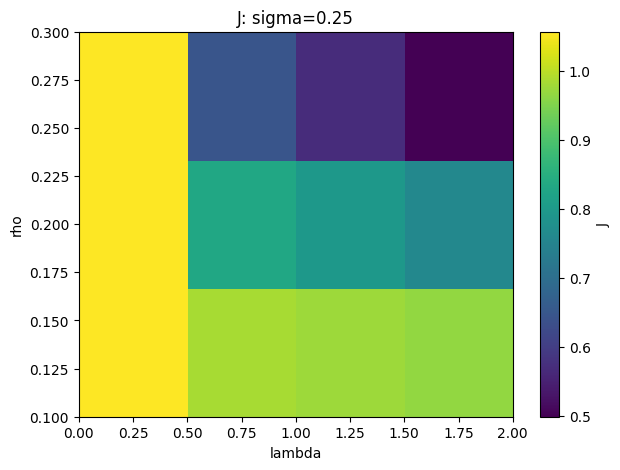

In [31]:
plot_heatmap(
    mean_df,
    "sigma", 0.25,
    "lambda", "rho",
    "J"
)

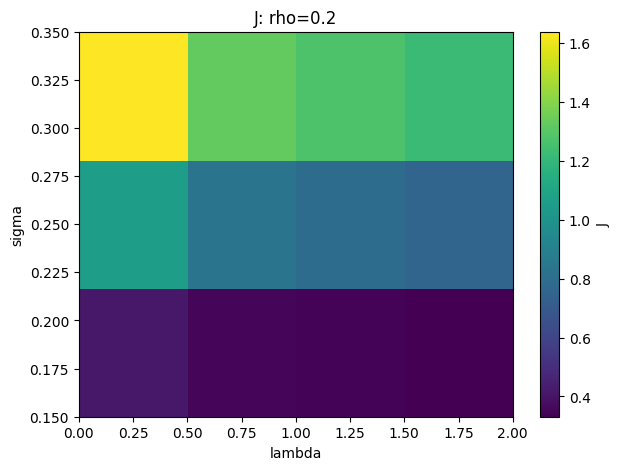

In [32]:
plot_heatmap(
    mean_df,
    "rho", 0.20,
    "lambda", "sigma",
    "J"
)

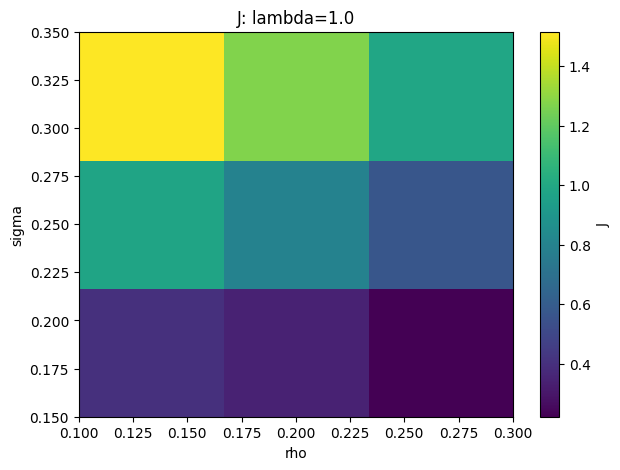

In [33]:
plot_heatmap(
    mean_df,
    "lambda", 1.0,
    "rho", "sigma",
    "J"
)

In [34]:
df

,n_lamps,sigma,rho,lambda,seed,J,avg_B,R
0,3,0.15,0.1,0.0,23,0.415045,0.415045,3.000000
1,3,0.15,0.1,0.0,54,0.415045,0.415045,3.000000
2,3,0.15,0.1,0.0,98,0.415045,0.415045,3.000000
3,3,0.15,0.1,0.5,23,0.405315,0.407147,0.003666
4,3,0.15,0.1,0.5,54,0.405319,0.407150,0.003663
...,...,...,...,...,...,...,...,...
427,8,0.35,0.3,1.0,54,-0.195579,2.206005,2.401583
428,8,0.35,0.3,1.0,98,-0.195578,2.206006,2.401584
429,8,0.35,0.3,2.0,23,-2.489822,2.059100,2.274461
430,8,0.35,0.3,2.0,54,-2.489822,2.059100,2.274461


In [35]:
def gif_for_parameter_grid(
    df, results, n_lamps, sigma, seed, nrows=3, ncols=4, interval=30
):
    subset = df[
        (df["n_lamps"] == n_lamps) & (df["sigma"] == sigma) & (df["seed"] == seed)
    ].copy()
    rhos = sorted(subset["rho"].unique())
    lambdas = sorted(subset["lambda"].unique())
    if len(rhos) != nrows:
        raise ValueError(f"Expected {nrows} rho values, found {len(rhos)}")
    if len(lambdas) != ncols:
        raise ValueError(f"Expected {ncols} lambda values, found {len(lambdas)}")
    if len(subset) != nrows * ncols:
        raise ValueError(f"Expected {nrows*ncols} runs, found {len(subset)}")
    states = {}

    for _, row in subset.iterrows():

        key = (
            int(row["n_lamps"]),
            row["sigma"],
            row["rho"],
            row["lambda"],
            int(row["seed"]),
        )

        states[(row["rho"], row["lambda"])] = results[key]
    histories = {}
    for rho in rhos:
        for lmbda in lambdas:
            state = states[(rho, lmbda)]
            history = state["history"]
            lamp_history = np.array(
                [
                    x.detach().cpu().numpy() if hasattr(x, "detach") else np.asarray(x)
                    for x in history["lamps"]
                ]
            )
            J_history = np.asarray(history["J"])
            B_history = np.asarray(history["avg_B"])
            histories[(rho, lmbda)] = {
                "lamps": lamp_history,
                "J": J_history,
                "B": B_history,
            }

    n_steps = len(list(histories.values())[0]["J"])
    x = np.linspace(0, 1, 150)
    y = np.linspace(0, 1, 150)
    X, Y = np.meshgrid(x, y)
    P = np.stack((X, Y), axis=-1)
    fig, axes = plt.subplots(nrows, ncols, figsize=(21, 12))
    axes = np.asarray(axes).flatten()
    images = []
    lamp_plots = []

    for row_idx, rho in enumerate(reversed(rhos)):
        for col_idx, lmbda in enumerate(lambdas):

            idx = row_idx * ncols + col_idx
            ax = axes[idx]
            state = states[(rho, lmbda)]
            hist = histories[(rho, lmbda)]
            positions = hist["lamps"][0]
            Z = np.zeros_like(X)
            for lamp in positions:

                Z += brightness(P, lamp, state["sigma"])
            im = ax.imshow(
                Z,
                extent=[0, 1, 0, 1],
                origin="lower",
                cmap="viridis",
                vmin=0,
                vmax=n_lamps,
            )

            images.append(im)
            (lamp_plot,) = ax.plot(
                positions[:, 0],
                positions[:, 1],
                "o",
                markersize=8,
                markeredgecolor="white",
            )
            lamp_plots.append(lamp_plot)

            J = hist["J"][0]
            avg_B = hist["B"][0]
            ax.set_title(
                f"$\\rho$={rho:.2f}, $\\lambda$={lmbda:.2f}\n"
                f"$J$={J:.4f}, avg B={avg_B:.4f}"
            )

            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xlabel("x")
            ax.set_ylabel("y")
            ax.set_aspect("equal")

    fig.colorbar(images[0], ax=axes.tolist(), label="Brightness", shrink=0.8)

    def update(frame):
        print(f"Rendering Frame {frame + 1}/{n_steps}\r", end="")
        idx = 0
        for rho in reversed(rhos):
            for lmbda in lambdas:

                ax = axes[idx]
                state = states[(rho, lmbda)]
                hist = histories[(rho, lmbda)]

                im = images[idx]
                lamp_plot = lamp_plots[idx]

                positions = hist["lamps"][frame]
                lamp_plot.set_data(positions[:, 0], positions[:, 1])

                Z = np.zeros_like(X)

                for lamp in positions:
                    Z += brightness(P, lamp, state["sigma"])

                im.set_data(Z)
                J = hist["J"][frame]
                avg_B = hist["B"][frame]

                ax.set_title(
                    f"$\\rho$={rho:.2f}, $\\lambda$={lmbda:.2f}\n"
                    f"$J$={J:.4f}, avg B={avg_B:.4f}"
                )

                idx += 1

        fig.suptitle(
            f"{n_lamps} Lamps | "
            f"$\\sigma$={sigma} | seed={seed} | "
            f"Step {frame + 1}/{n_steps}",
            fontsize=32,
        )

        return images + lamp_plots

    anim = FuncAnimation(fig, update, frames=n_steps, interval=interval, blit=False)

    print()

    plt.close(fig)

    return anim

### GIF 3 Lamps

In [22]:
anim = gif_for_parameter_grid(
    df,
    results,
    n_lamps=3,
    sigma=0.25,
    seed=23
)

In [ ]:
HTML(anim.to_jshtml())
# For having small notebook size this output has been cleared. you can view the gif at
#  https://jsmaskeen.github.io/DL-Assignment-1/animation_89_3.html
# or you can run this cell!
import requests
HTML(requests.get('https://raw.githubusercontent.com/jsmaskeen/DL-Assignment-1/main/artifacts/single_notebook/animation_89_3.html').text)

### GIF 4 Lamps

In [24]:
anim = gif_for_parameter_grid(
    df,
    results,
    n_lamps=4,
    sigma=0.25,
    seed=23
)

In [ ]:
HTML(anim.to_jshtml())
# For having small notebook size this output has been cleared. you can view the gif at
#  https://jsmaskeen.github.io/DL-Assignment-1/animation_92_3.html
# or you can run this cell!
import requests
HTML(requests.get('https://raw.githubusercontent.com/jsmaskeen/DL-Assignment-1/main/artifacts/single_notebook/animation_92_3.html').text)

### GIF 6 Lamps

In [26]:
anim = gif_for_parameter_grid(
    df,
    results,
    n_lamps=6,
    sigma=0.25,
    seed=23
)

In [ ]:
HTML(anim.to_jshtml())
# For having small notebook size this output has been cleared. you can view the gif at
#  https://jsmaskeen.github.io/DL-Assignment-1/animation_95_3.html
# or you can run this cell!
import requests
HTML(requests.get('https://raw.githubusercontent.com/jsmaskeen/DL-Assignment-1/main/artifacts/single_notebook/animation_95_3.html').text)

### GIF 8 Lamps

In [28]:
anim = gif_for_parameter_grid(
    df,
    results,
    n_lamps=8,
    sigma=0.25,
    seed=23
)

In [ ]:
HTML(anim.to_jshtml())
# For having small notebook size this output has been cleared. you can view the gif at
#  https://jsmaskeen.github.io/DL-Assignment-1/animation_98_3.html
# or you can run this cell!
import requests
HTML(requests.get('https://raw.githubusercontent.com/jsmaskeen/DL-Assignment-1/main/artifacts/single_notebook/animation_98_3.html').text)

## Observations


**1. Effect of Random Seeds on Final Placement**
When running the optimization from different random seeds (e.g., seeds 23, 54, and 98) with identical hyperparameters, the final objective values ($J$) and average brightness ($avg\_B$) are nearly identical. This shows that the optimizers consistently converge to equivalent optimal placements regardless of the random initialization, though the specific symmetric arrangement of the lamps might vary.

**2. Varying the Constants ($\sigma$, $\rho$, $\lambda$)**
* **Varying $\lambda$ (Repulsion Weight):** When $\lambda = 0.0$, there is no penalty for lamps being too close together. As a result, the optimization places all lamps collapsed together in the center of the room to maximize the peak brightness in the center. As $\lambda$ is increased (e.g., to $0.5$, $1.0$, $2.0$), the repulsion penalty forces the lamps to spread out. This lowers the absolute average brightness slightly but significantly reduces the repulsion overlap penalty, leading to a much better spread of light across the room.
* **Varying $\sigma$ (Light Spread):** A larger $\sigma$ (e.g., $0.35$ vs $0.15$) means each lamp throws light further across the room. This naturally results in a significantly higher total average brightness ($avg\_B$) because the light reaches farther than before.
* **Varying $\rho$ (Repulsion Range):** Increasing $\rho$ increases the effective radius over which lamps push each other away. A larger $\rho$ forces the lamps closer to the walls and corners to avoid the penalty.

**3. Effect of Adding More Lamps (4, 6, 8)**
As the number of lamps increases from 3 to 8, the overall average brightness of the room ($avg\_B$) scales up significantly. With more lamps, it becomes harder for them to avoid each other in the confined $[0, 1]^2$ unit-square room, so the base repulsion penalty $R$ increases, requiring them to pack into more intricate geometric patterns (such as perfect shapes: Square, Hexagon, or Octagon) to balance brightness and repulsion.